Task 1: ML Environment Setup

In [1]:
pip install numpy pandas matplotlib scikit-learn

Task 3: Data Preprocessing

In [23]:
import pandas as pd

employees = pd.DataFrame({
    "age":[22,25,28,None,35,40,None,29],
    "salary":[25000,30000,None,45000,50000,70000,38000,None],
    "experience":[1,2,3,5,None,12,2,4]
})
print(employees)

    age   salary  experience
0  22.0  25000.0         1.0
1  25.0  30000.0         2.0
2  28.0      NaN         3.0
3   NaN  45000.0         5.0
4  35.0  50000.0         NaN
5  40.0  70000.0        12.0
6   NaN  38000.0         2.0
7  29.0      NaN         4.0


In [24]:
# missing values
missing_before = employees.isnull().sum()
print(missing_before)

age           2
salary        2
experience    1
dtype: int64


In [10]:
# filling missing values
employees["age"]=employees["age"].fillna(employees["age"].mean())
employees["salary"]=employees["salary"].fillna(employees["salary"].mean())
employees["experience"]= employees["experience"].fillna(employees["experience"].mean())

In [25]:
#option 2 filling missing values
employees.fillna(employees.mean(), inplace= True)

missing_after = employees.isnull().sum()
print(missing_after)

age           0
salary        0
experience    0
dtype: int64


In [28]:
# Validation
invalid_values = (employees < 0).sum()
with open("preprocessing_report.txt","w") as file:
  file.write("DATA PREPROCESSING REPORT \n")
  file.write("="*40 +"\n\n")

  file.write("Missing Values Before Preprocessing:\n")
  file.write(str(missing_before))
  file.write("\n\n")

  file.write("Missing Values After Preprocessing:\n")
  file.write(str(missing_after))
  file.write("\n\n")

  file.write("Invalida Values:\n")
  file.write(str(invalid_values))
  file.write("\n\n")

print("Report generated successfully.")

Report generated successfully.


Task 4: Feature Engineering

In [32]:
import pandas as pd

employees = pd.DataFrame({
    "salary":[25000,30000,45000,50000,70000],
    "experience":[1,2,5,7,12]
})

def Salary_category(salary):
  if salary <=30000:
    return "Low"
  if salary <= 55000:
    return "Medium"
  else:
    return "High"

def Experience_category(exp):
  if exp <= 3:
    return "Junior"
  if exp <= 8:
    return "Mid"
  else:
    return "Senior"
  employees["Salary_category"]=employees["salary"].apply(Salary_category)
  employees["Experience_category"]=employees["experience"].apply(Experience_category)
  employees.to_csv("employees_data.csv",index= False)
  print(employees)

Task 5: Train First ML Model

In [39]:
from sklearn.linear_model import LinearRegression
import numpy as np

experience = np.array([1,2,3,5,7,10,12,15]).reshape(-1,1)
salary = np.array([25000,30000,35000,45000,55000,70000,85000,100000]).reshape(-1,1)

model = LinearRegression()
model.fit(experience,salary)

years = np.array([4,8,20]).reshape(-1,1)
predictions = model.predict(years)

for year, sal in zip([4,8,20],predictions):
  print(f"Experience: {year} years")
  print(f"Predicted Salary: ₹ {sal[0]:.2f}")
  print()

Experience: 4 years
Predicted Salary: ₹ 40185.19

Experience: 8 years
Predicted Salary: ₹ 61666.67

Experience: 20 years
Predicted Salary: ₹ 126111.11



Task 6: Model Evaluation

In [44]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

import numpy as np

print(employees)

model = LinearRegression()
model.fit(experience,salary)

predictions = model.predict(experience)

mae = mean_absolute_error(salary,predictions)
print(f"Mean Absolute Error: {mae:.2f}\n")

mse = mean_squared_error(salary,predictions)
print(f"Mean Squared Error: {mse:.2f}\n")

r2 = r2_score(salary, predictions)
print(f"r2_score : {r2:.2f}")

with open("model_evaluation.txt","w") as file:
  file.write("Model Evaluation Report \n")
  file.write("="*40 + "\n\n")

  file.write(f"Mean Absolute Error: {mae:.2f}")
  file.write('\n\n')
  file.write(f"Mean Squared Error: {mse:.2f}")
  file.write('\n\n')
  file.write(f"r2_score: {r2:.2f}")
  file.write('\n\n')
print("Report submitted successfully")

   salary  experience
0   25000           1
1   30000           2
2   45000           5
3   50000           7
4   70000          12
Mean Absolute Error: 1064.81

Mean Squared Error: 1620370.37

r2_score : 1.00
Report submitted successfully


Task 7: Classification Model

In [55]:
from sklearn.tree import DecisionTreeClassifier
import numpy as np

experience = np.array([1,2,3,5,7,10,12,15]).reshape(-1,1)
status = ["Junior","Junior","Junior","Mid","Mid","Senior","Senior","Senior"]

model = DecisionTreeClassifier()
model.fit(experience,status)

test = np.array([4,8,13]).reshape(-1,1)
predictions = model.predict(test)

for exp,category in zip([4,8,13],predictions):
  print(f"{exp} Years Experience ->{category}")


4 Years Experience ->Junior
8 Years Experience ->Mid
13 Years Experience ->Senior


Task 8: Visualization

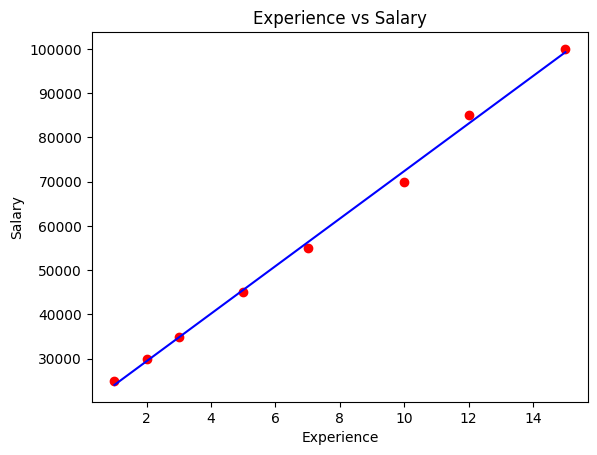

In [57]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

experience = np.array([1,2,3,5,7,10,12,15]).reshape(-1,1)
salary = np.array([25000,30000,35000,45000,55000,70000,85000,100000])

model = LinearRegression()
model.fit(experience,salary)

predictions = model.predict(experience)
plt.scatter(experience,salary,color='red')
plt.plot(experience,predictions,color='blue')
plt.title("Experience vs Salary")
plt.xlabel("Experience")
plt.ylabel("Salary")
plt.show()

Bonus Challenge - Employee Salary Predictor

In [62]:
import numpy as np
from sklearn.linear_model import LinearRegression

experience = np.array([1,2,3,5,7,10,12,15]).reshape(-1,1)
salary = np.array([25000,30000,35000,45000,55000,70000,85000,100000])

model = LinearRegression()
while True:
  print("\n Employee Salary Predictor")
  print("1. Train Model")
  print("2. Predict Salary")
  print("3. Evaluate MOdel")
  print("4. Export Predictions")
  print("5. Exit")

  choice = input("Enter your choice:")

  if choice == "1":
    model.fit(experience,salary)
    print("Model Trained Successfully")

  elif choice == "2":
    exp = float(input("Enter the Experience"))
    predicted_salary = model.predict([[exp]])
    print("Predicted Salary =",round(predicted_salary[0], 2))

  elif choice == "3":
    score = model.score(experience,salary)
    print("Model Accuracy (R2 Score) =",round(score,2))

  elif choice == "4":
    predictions = model.predict(experience)
    file = open("predictions.txt","w")
    for exp, sal in zip(experience.flatten(),predictions):
      file.write(f"{exp} Years ->{round(sal,2)}\n")
    file.close()

    print("Predictions exported to predictions.txt")
  elif choice == "5":
    print("Program ended")
    break
  else:
    print("Invalid choice")



 Employee Salary Predictor
1. Train Model
2. Predict Salary
3. Evaluate MOdel
4. Export Predictions
5. Exit
Enter your choice:1
Model Trained Successfully

 Employee Salary Predictor
1. Train Model
2. Predict Salary
3. Evaluate MOdel
4. Export Predictions
5. Exit
Enter your choice:2
Enter the Experience5
Predicted Salary = 45555.56

 Employee Salary Predictor
1. Train Model
2. Predict Salary
3. Evaluate MOdel
4. Export Predictions
5. Exit
Enter your choice:3
Model Accuracy (R2 Score) = 1.0

 Employee Salary Predictor
1. Train Model
2. Predict Salary
3. Evaluate MOdel
4. Export Predictions
5. Exit
Enter your choice:4
Predictions exported to predictions.txt

 Employee Salary Predictor
1. Train Model
2. Predict Salary
3. Evaluate MOdel
4. Export Predictions
5. Exit
Enter your choice:5
Program ended
